In [1]:
import pandas as pd
import numpy as np
from statsmodels.datasets import get_rdataset
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from ISLP import load_data

from sklearn.cluster import (KMeans, AgglomerativeClustering)
from scipy.cluster.hierarchy import (dendrogram, cut_tree, fcluster)
from ISLP.cluster import compute_linkage
import matplotlib.pyplot as plt

### Load Datasets

In [2]:
base_folder = "datasets/olist/"
olist_order_reviews = pd.read_csv(base_folder + "olist_order_reviews_dataset.csv").set_index("review_id")
olist_orders = pd.read_csv(base_folder + "olist_orders_dataset.csv").set_index("order_id")
olist_products = pd.read_csv(base_folder + "olist_products_dataset.csv").set_index("product_id")
product_category_name_translation = pd.read_csv(base_folder + "product_category_name_translation.csv").set_index("product_category_name")
olist_geolocation = pd.read_csv(base_folder + "olist_geolocation_dataset.csv")
olist_order_items = pd.read_csv(base_folder + "olist_order_items_dataset.csv")
olist_order_payments = pd.read_csv(base_folder + "olist_order_payments_dataset.csv")
olist_customers = pd.read_csv(base_folder + "olist_customers_dataset.csv").set_index("customer_id")
olist_sellers = pd.read_csv(base_folder + "olist_sellers_dataset.csv").set_index("seller_id")

In [3]:
average_order_reviews = olist_order_reviews.groupby("order_id")["review_score"].mean().rename("average_review")
total_order_payments = olist_order_payments.groupby("order_id")["payment_value"].sum().rename("total_payment")
olist_orders_joined = olist_orders.join(average_order_reviews).join(total_order_payments).join(olist_customers, on="customer_id", how="outer")
olist_order_items_joined = olist_order_items.join(olist_products, on="product_id", how="outer").join(olist_sellers, on="seller_id", how="outer").join(olist_orders_joined, on="order_id", how="outer")
olist_order_payments_joined = olist_order_payments.join(olist_orders_joined, on="order_id", how="outer")


### Data Processing

In [4]:
    olist_products

,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
product_id,,,,,,,,
1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,40.0,287.0,1.0,225.0,16.0,10.0,14.0
3aa071139cb16b67ca9e5dea641aaa2f,artes,44.0,276.0,1.0,1000.0,30.0,18.0,20.0
96bd76ec8810374ed1b65e291975717f,esporte_lazer,46.0,250.0,1.0,154.0,18.0,9.0,15.0
cef67bcfe19066a932b7673e239eb23d,bebes,27.0,261.0,1.0,371.0,26.0,4.0,26.0
9dc1a7de274444849c219cff195d0b71,utilidades_domesticas,37.0,402.0,4.0,625.0,20.0,17.0,13.0
...,...,...,...,...,...,...,...,...
a0b7d5a992ccda646f2d34e418fff5a0,moveis_decoracao,45.0,67.0,2.0,12300.0,40.0,40.0,40.0
bf4538d88321d0fd4412a93c974510e6,construcao_ferramentas_iluminacao,41.0,971.0,1.0,1700.0,16.0,19.0,16.0
9a7c6041fa9592d9d9ef6cfe62a71f8c,cama_mesa_banho,50.0,799.0,1.0,1400.0,27.0,7.0,27.0


In [5]:
olist_order_items_joined

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,product_category_name,product_name_lenght,product_description_lenght,...,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,average_review,total_payment,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0.0,00010242fe8c5a6d1ba2dd792cb16214,1.0,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29,cool_stuff,58.0,598.0,...,2017-09-13 09:45:35,2017-09-19 18:34:16,2017-09-20 23:43:48,2017-09-29 00:00:00,5.0,72.19,871766c5855e863f6eccc05f988b23cb,28013,campos dos goytacazes,RJ
1.0,00018f77f2f0320c557190d7a144bdd3,1.0,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93,pet_shop,56.0,239.0,...,2017-04-26 11:05:13,2017-05-04 14:35:00,2017-05-12 16:04:24,2017-05-15 00:00:00,4.0,259.83,eb28e67c4c0b83846050ddfb8a35d051,15775,santa fe do sul,SP
2.0,000229ec398224ef6ca0657da4fc703e,1.0,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87,moveis_decoracao,59.0,695.0,...,2018-01-14 14:48:30,2018-01-16 12:36:48,2018-01-22 13:19:16,2018-02-05 00:00:00,5.0,216.87,3818d81c6709e39d06b2738a8d3a2474,35661,para de minas,MG
3.0,00024acbcdf0a6daa1e931b038114c75,1.0,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79,perfumaria,42.0,480.0,...,2018-08-08 10:10:18,2018-08-10 13:28:00,2018-08-14 13:32:39,2018-08-20 00:00:00,4.0,25.78,af861d436cfc08b2c2ddefd0ba074622,12952,atibaia,SP
4.0,00042b26cf59d7ce69dfabb4e55b4fd9,1.0,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14,ferramentas_jardim,59.0,409.0,...,2017-02-04 14:10:13,2017-02-16 09:46:09,2017-03-01 16:42:31,2017-03-17 00:00:00,5.0,218.04,64b576fb70d441e8f1b2d7d446e483c5,13226,varzea paulista,SP
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
112645.0,fffc94f6ce00a00581880bf54a75a037,1.0,4aa6014eceb682077f9dc4bffebc05b0,b8bc237ba3788b23da09c0f1f3a3288c,2018-05-02 04:11:01,299.99,43.41,utilidades_domesticas,43.0,1002.0,...,2018-04-25 04:11:01,2018-04-25 12:09:00,2018-05-10 22:56:40,2018-05-18 00:00:00,5.0,343.40,0c9aeda10a71f369396d0c04dce13a64,65077,sao luis,MA
112646.0,fffcd46ef2263f404302a634eb57f7eb,1.0,32e07fd915822b0765e448c4dd74c828,f3c38ab652836d21de61fb8314b69182,2018-07-20 04:31:48,350.00,36.53,informatica_acessorios,31.0,232.0,...,2018-07-17 04:31:48,2018-07-17 08:05:00,2018-07-23 20:31:55,2018-08-01 00:00:00,5.0,386.53,0da9fe112eae0c74d3ba1fe16de0988b,81690,curitiba,PR
112647.0,fffce4705a9662cd70adb13d4a31832d,1.0,72a30483855e2eafc67aee5dc2560482,c3cfdc648177fdbbbb35635a37472c53,2017-10-30 17:14:25,99.90,16.95,esporte_lazer,43.0,869.0,...,2017-10-24 17:14:25,2017-10-26 15:13:14,2017-10-28 12:22:22,2017-11-10 00:00:00,5.0,116.85,cd79b407828f02fdbba457111c38e4c4,4039,sao paulo,SP
112648.0,fffe18544ffabc95dfada21779c9644f,1.0,9c422a519119dcad7575db5af1ba540e,2b3e4a2a3ea8e01938cabda2a3e5cc79,2017-08-21 00:04:32,55.99,8.72,informatica_acessorios,56.0,1306.0,...,2017-08-15 00:04:32,2017-08-15 19:02:53,2017-08-16 21:59:40,2017-08-25 00:00:00,5.0,64.71,eb803377c9315b564bdedad672039306,13289,vinhedo,SP


In [6]:
olist_clustering_seller = olist_order_items_joined.dropna().groupby("seller_id").agg({"price": ["mean", "sum"], "product_name_lenght": "mean", "product_description_lenght": "mean", "product_photos_qty": "mean", "product_weight_g":"mean", "product_length_cm": "mean", "product_height_cm": "mean", "product_width_cm": "mean", "product_id": ["nunique", "count"]})
olist_clustering_seller.columns = olist_clustering_seller.columns.to_flat_index()

In [7]:
olist_clustering_seller.columns = ["_".join(a) for a in olist_clustering_seller.columns]

In [8]:
#olist_clustering_seller = olist_clustering_seller.join(olist_sellers)

In [9]:
#olist_clustering_seller.seller_city = olist_clustering_seller.seller_city.astype("category")
#olist_clustering_seller.seller_state = olist_clustering_seller.seller_state.astype("category")

In [10]:
olist_clustering_seller

,price_mean,price_sum,product_name_lenght_mean,product_description_lenght_mean,product_photos_qty_mean,product_weight_g_mean,product_length_cm_mean,product_height_cm_mean,product_width_cm_mean,product_id_nunique,product_id_count
seller_id,,,,,,,,,,,
0015a82c2db000af6aaaf3ae2ecb0532,895.000000,2685.00,40.000000,849.000000,2.000000,11800.000000,40.000000,43.000000,36.000000,1,3
001cca7ae9ae17fb1caed9dfb1094831,104.662468,24177.03,35.826840,472.164502,1.796537,8979.870130,41.580087,12.844156,39.108225,11,231
002100f778ceb8431b7a1020ff7ab48f,22.529630,1216.60,55.240741,654.000000,1.000000,332.407407,16.074074,28.444444,19.555556,24,54
004c9cd9d87a3c30c522c48c4fc07416,113.671503,17391.74,56.104575,523.568627,1.039216,2121.620915,36.816993,11.490196,34.751634,77,153
00720abe85ba0859807595bbf045a33b,38.750000,1007.50,43.576923,493.192308,2.230769,525.000000,25.000000,10.384615,36.038462,9,26
...,...,...,...,...,...,...,...,...,...,...,...
ffc470761de7d0232558ba5e786e57b7,50.971000,1529.13,55.033333,820.900000,1.533333,726.400000,20.666667,14.833333,18.866667,15,30
ffdd9f82b9a447f6f8d4b91554cc7dd3,105.060000,2101.20,49.050000,525.300000,1.200000,5345.850000,32.600000,26.100000,26.250000,12,20
ffeee66ac5d5a62fe688b9d26f83f534,131.418571,1839.86,55.357143,801.285714,4.928571,7325.000000,30.000000,47.214286,41.071429,3,14


In [11]:
scaler = StandardScaler()
features = olist_clustering_seller.copy()
scaled_features = scaler.fit_transform(features)

In [12]:
# Perform K-Means clustering with K=5
kmeans = KMeans(n_clusters=9, random_state=10)
features['Cluster'] = kmeans.fit_predict(scaled_features)

# Display a sample of the data with cluster assignments
features.head()


,price_mean,price_sum,product_name_lenght_mean,product_description_lenght_mean,product_photos_qty_mean,product_weight_g_mean,product_length_cm_mean,product_height_cm_mean,product_width_cm_mean,product_id_nunique,product_id_count,Cluster
seller_id,,,,,,,,,,,,
0015a82c2db000af6aaaf3ae2ecb0532,895.000000,2685.00,40.000000,849.000000,2.000000,11800.000000,40.000000,43.000000,36.000000,1,3,6
001cca7ae9ae17fb1caed9dfb1094831,104.662468,24177.03,35.826840,472.164502,1.796537,8979.870130,41.580087,12.844156,39.108225,11,231,4
002100f778ceb8431b7a1020ff7ab48f,22.529630,1216.60,55.240741,654.000000,1.000000,332.407407,16.074074,28.444444,19.555556,24,54,5
004c9cd9d87a3c30c522c48c4fc07416,113.671503,17391.74,56.104575,523.568627,1.039216,2121.620915,36.816993,11.490196,34.751634,77,153,1
00720abe85ba0859807595bbf045a33b,38.750000,1007.50,43.576923,493.192308,2.230769,525.000000,25.000000,10.384615,36.038462,9,26,2


In [13]:
numeric_columns = features.select_dtypes(include=['float64', 'int64']).columns

# Analyze cluster characteristics
cluster_summary = features.groupby('Cluster')[numeric_columns].mean()

cluster_summary["counts"] = features.Cluster.value_counts()

# Display the cluster summary
cluster_summary


,price_mean,price_sum,product_name_lenght_mean,product_description_lenght_mean,product_photos_qty_mean,product_weight_g_mean,product_length_cm_mean,product_height_cm_mean,product_width_cm_mean,product_id_nunique,product_id_count,counts
Cluster,,,,,,,,,,,,
0,1073.785708,9743.532667,48.689881,1695.878028,2.841658,6258.862720,35.896233,26.134342,28.032751,5.186667,10.533333,75
1,128.997789,27681.160370,48.989290,776.585937,2.002912,1699.143337,28.778906,15.409124,22.699711,74.377778,256.607407,135
2,93.365224,1364.958976,34.883707,655.310835,1.666690,1051.098875,24.967978,14.825697,18.911655,5.995549,14.329377,674
3,165.561249,137955.356111,50.658561,666.581387,2.262404,2179.795828,29.679745,18.068192,23.254202,173.888889,1179.000000,18
4,174.749283,2771.207885,48.201354,710.782252,2.199118,4919.588042,50.283851,20.854954,35.714738,7.425051,20.934292,487
5,113.754137,2089.530953,51.119106,927.915974,1.726878,1032.433986,24.469798,14.559261,18.220133,8.177570,20.804673,1070
6,522.680028,4571.543909,48.453586,943.713280,2.867495,18325.418296,56.129722,54.814597,41.047418,4.381818,13.336364,110
7,3777.801481,7267.268889,43.633333,1942.655556,2.777778,10395.000000,36.944444,37.044444,30.788889,1.444444,2.222222,9
8,147.867380,2753.226254,51.844163,1114.444069,5.017368,1485.426734,29.198306,16.035852,20.893308,7.410876,22.870091,331


In [14]:
# features were already scaled in previous steps

# Step 2: Hierarchical Clustering with Complete Linkage
hc_comp = AgglomerativeClustering(1, compute_distances=True)
hc_comp.fit(scaled_features)

AgglomerativeClustering(compute_distances=True, n_clusters=1)

In [15]:
# Step 3: Create Linkage Matrix for the Dendrogram (custom computation)
def compute_linkage(model):
    n_samples = len(model.labels_)
    counts = np.zeros(model.children_.shape[0])
    for i, merge in enumerate(model.children_):
        counts[i] = counts[i] + (merge < n_samples).sum()
    linkage_matrix = np.column_stack([model.children_, model.distances_, counts]).astype(float)
    return linkage_matrix


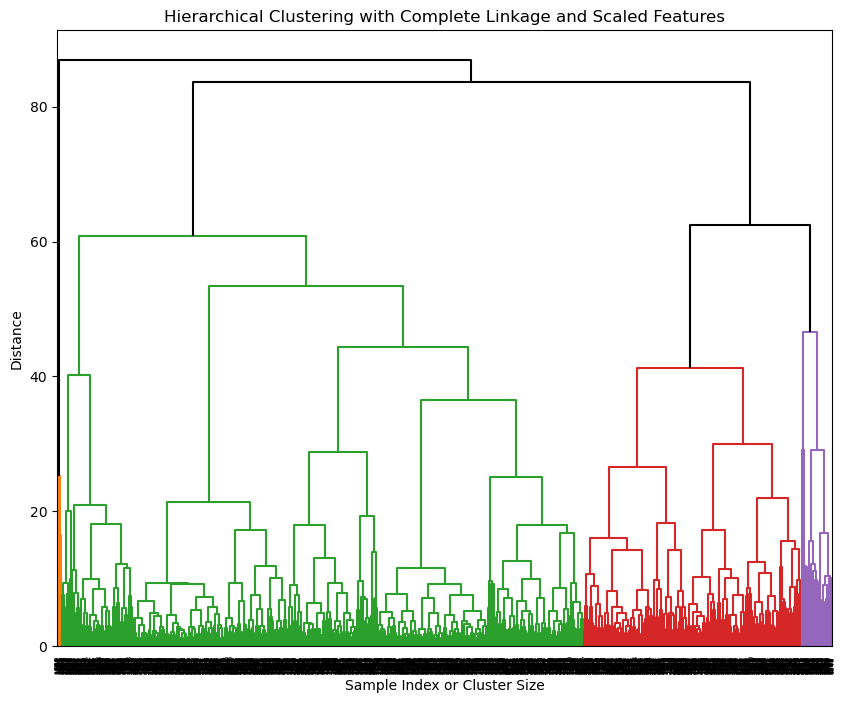

In [16]:
# Step 4: Compute the Linkage Matrix and Plot the Dendrogram
linkage_comp = compute_linkage(hc_comp)
fig, ax = plt.subplots(1, 1, figsize=(10, 8))
dendrogram(linkage_comp, ax=ax, color_threshold=61, above_threshold_color='black')
ax.set_title("Hierarchical Clustering with Complete Linkage and Scaled Features")
ax.set_xlabel("Sample Index or Cluster Size")
ax.set_ylabel("Distance")
plt.show()


In [17]:
features["Cluster"] = fcluster(linkage_comp, 61, criterion="distance")

In [18]:
numeric_columns = features.select_dtypes(include=['float64', 'int64']).columns

# Analyze cluster characteristics
cluster_summary = features.groupby('Cluster')[numeric_columns].mean()

cluster_summary["counts"] = features.Cluster.value_counts()

# Display the cluster summary
cluster_summary


,price_mean,price_sum,product_name_lenght_mean,product_description_lenght_mean,product_photos_qty_mean,product_weight_g_mean,product_length_cm_mean,product_height_cm_mean,product_width_cm_mean,product_id_nunique,product_id_count,counts
Cluster,,,,,,,,,,,,
1,183.453508,147286.307059,49.059470,777.276373,2.050418,2365.242133,27.999101,18.592886,22.504788,144.529412,1143.705882,17
2,122.812323,3937.680464,45.983529,898.921782,2.195008,1079.586320,24.618912,13.945009,19.071599,12.816004,37.727829,1962
3,184.985746,2584.204914,48.206940,758.315684,2.382974,4289.929805,43.074236,24.262117,29.458154,6.087010,16.664216,816
4,1018.341960,5241.775088,46.953720,1045.776188,2.469507,16571.112527,60.135820,37.628288,44.646121,3.035088,6.684211,114


In [49]:
(cluster_summary["price_sum"] * cluster_summary["counts"]).sum()

12935869.86

In [21]:
cluster_names = [
    "High Variety, High Volume",
    "Low Price, Medium volume",
    "Medium Price, Low Volume",
    "High Price, Little Sales",
]

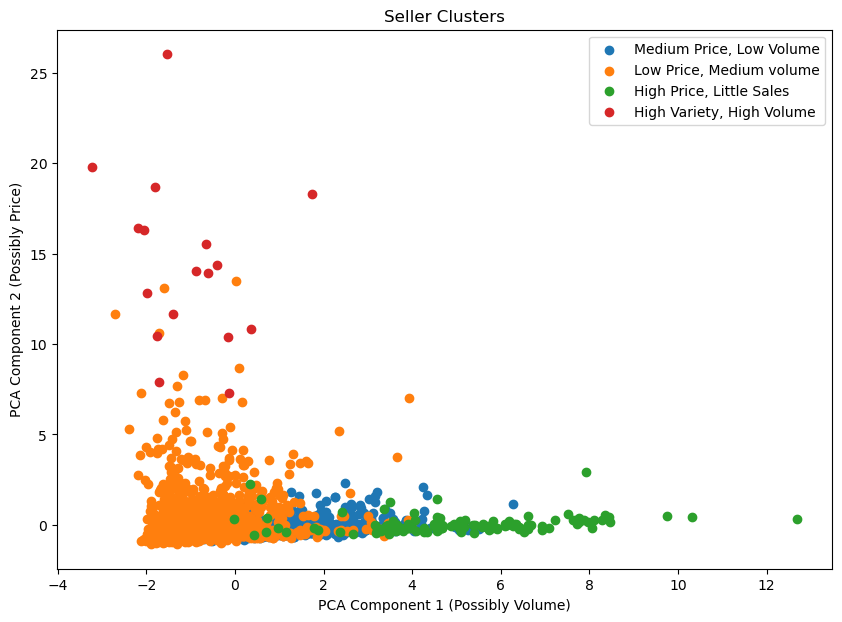

In [26]:
# Perform PCA
pca = PCA(n_components=2)
pca.fit(scaled_features)
pca_features = pca.transform(scaled_features)

plt.figure(figsize=(10, 7))

for cluster_id in features['Cluster'].unique():
    cluster_points = pca_features[features['Cluster'] == cluster_id]
    plt.scatter(cluster_points[:, 0], cluster_points[:, 1], label=cluster_names[cluster_id - 1])

# Step 3: Add labels and legend
plt.xlabel('PCA Component 1 (Possibly Price)')
plt.ylabel('PCA Component 2 (Possibly Volume)')
plt.title('Seller Clusters')
plt.legend()
plt.show()


<Figure size 1000x700 with 0 Axes>

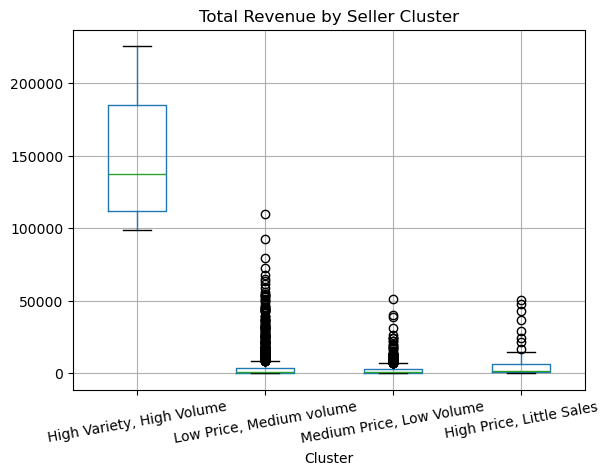

In [38]:
# Box plot of Seller Sum Prices
plt.figure(figsize=(10, 7))
features.boxplot(column="price_sum", by="Cluster")
plt.title("Total Revenue by Seller Cluster")
plt.xticks(ticks=range(1, 5), labels=cluster_names, rotation=10)
plt.suptitle("")
plt.show()

<Figure size 1000x700 with 0 Axes>

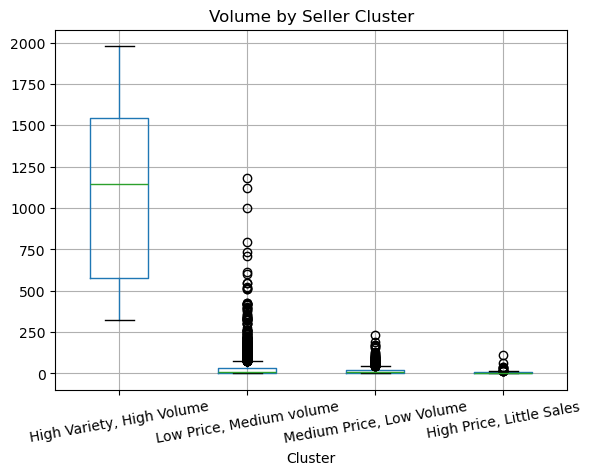

In [45]:
# Box plot of Seller Sum Prices
plt.figure(figsize=(10, 7))
features.boxplot(column="product_id_count", by="Cluster")
plt.title("Volume by Seller Cluster")
plt.xticks(ticks=range(1, 5), labels=cluster_names, rotation=10)
plt.suptitle("")
plt.show()